In [ ]:
library(Seurat)

In [ ]:
library(tidyverse)

In [3]:
data <-readRDS('GCA_obj_subset_excludecells3.Rdata')

In [32]:
lownames <- readRDS('lownames.rds')
highnames <- readRDS('highnames.rds')

In [33]:
high_cnv <- readRDS('infercnv_low2/Low_low_cnv.names.Rds')

In [34]:
low_cnv <- readRDS('infercnv_low2/Low_high_cnv.names.Rds')

In [35]:
data@meta.data  %>% filter(celltype=='Epi_tumor')  %>% rownames()  %>% data[,.]  -> data_epi

In [36]:
data_epi@meta.data  %>% filter(sample  %in% lownames)  %>% rownames()  %>% data_epi[,.] -> data_epi_high

In [37]:
data_epi_high@meta.data$cnv = 'non'

In [38]:
data_epi_high@meta.data[high_cnv,'cnv'] <- 'High'
data_epi_high@meta.data[low_cnv,'cnv'] <- 'Low'

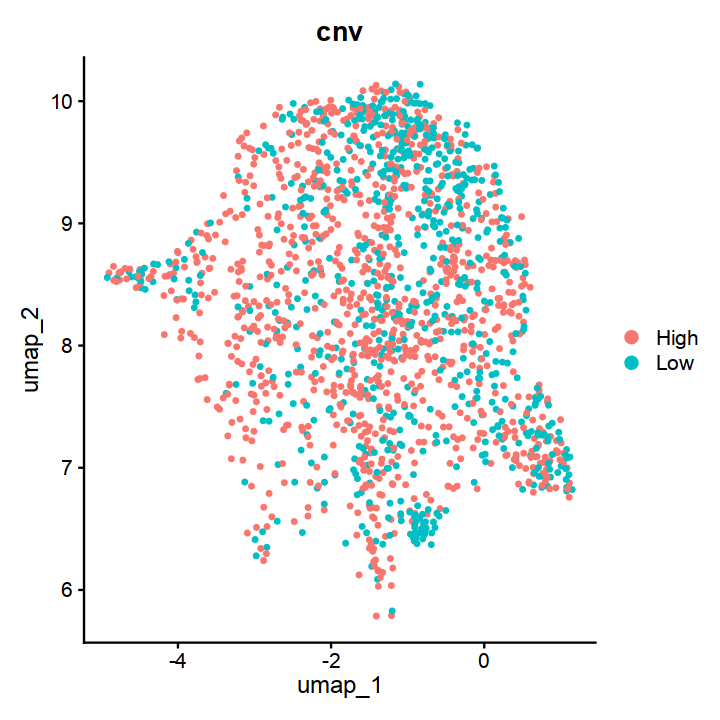

In [54]:
# Visualization
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi_high, reduction = "umap", group.by = c("cnv"))

In [40]:
data_epi_high[["RNA"]] <- split(data_epi_high[["RNA"]],
                                           f = data_epi_high$sample)

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.



In [41]:
data_epi_high <- NormalizeData(data_epi_high, normalization.method = "LogNormalize", 
                                           scale.factor = 10000)

Normalizing layer: counts.SC005

Normalizing layer: counts.SC008

Normalizing layer: counts.SC027



In [ ]:
all.genes <- rownames(data_epi_high)
data_epi_high <- FindVariableFeatures(data_epi_high, selection.method = "vst", 
                                                  nfeatures = 2000)
data_epi_high <- ScaleData(data_epi_high, features = all.genes)
data_epi_high <- RunPCA(data_epi_high, features = 
                                    VariableFeatures(object = data_epi_high))

In [43]:
data_epi_high2 <- IntegrateLayers(object = data_epi_high, method = CCAIntegration, orig.reduction = "pca",
                        new.reduction = "integrated.cca",verbose = FALSE)

In [44]:
# re-join layers after integration
data_epi_high2[["RNA"]] <- JoinLayers(data_epi_high2[["RNA"]])

In [45]:
data_epi_high2 <- FindNeighbors(data_epi_high2, dims = 1:30,reduction = "integrated.cca")

Computing nearest neighbor graph

Computing SNN



In [46]:
data_epi_high2 <- FindClusters(data_epi_high2, resolution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1756
Number of edges: 80508

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7871
Number of communities: 8
Elapsed time: 0 seconds


In [ ]:
data_epi_high2 <- RunUMAP(data_epi_high2, dims = 1:30,reduction = "integrated.cca")

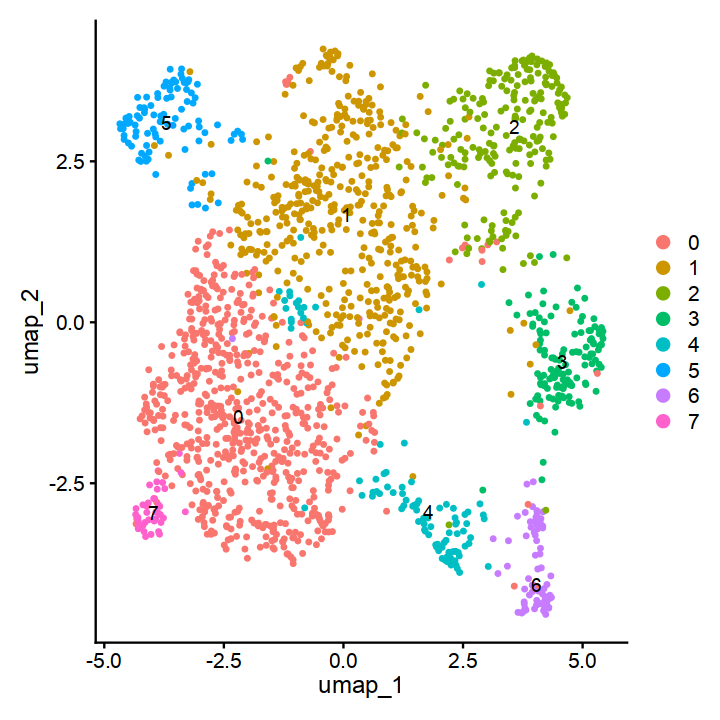

In [48]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi_high2, reduction = "umap", label = TRUE)

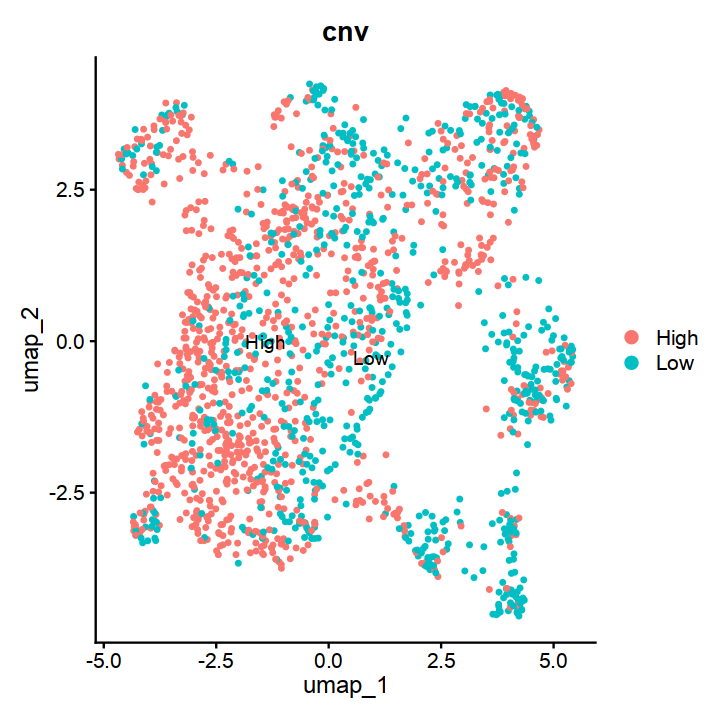

In [49]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi_high2, reduction = "umap", label = TRUE,group.by ="cnv" )

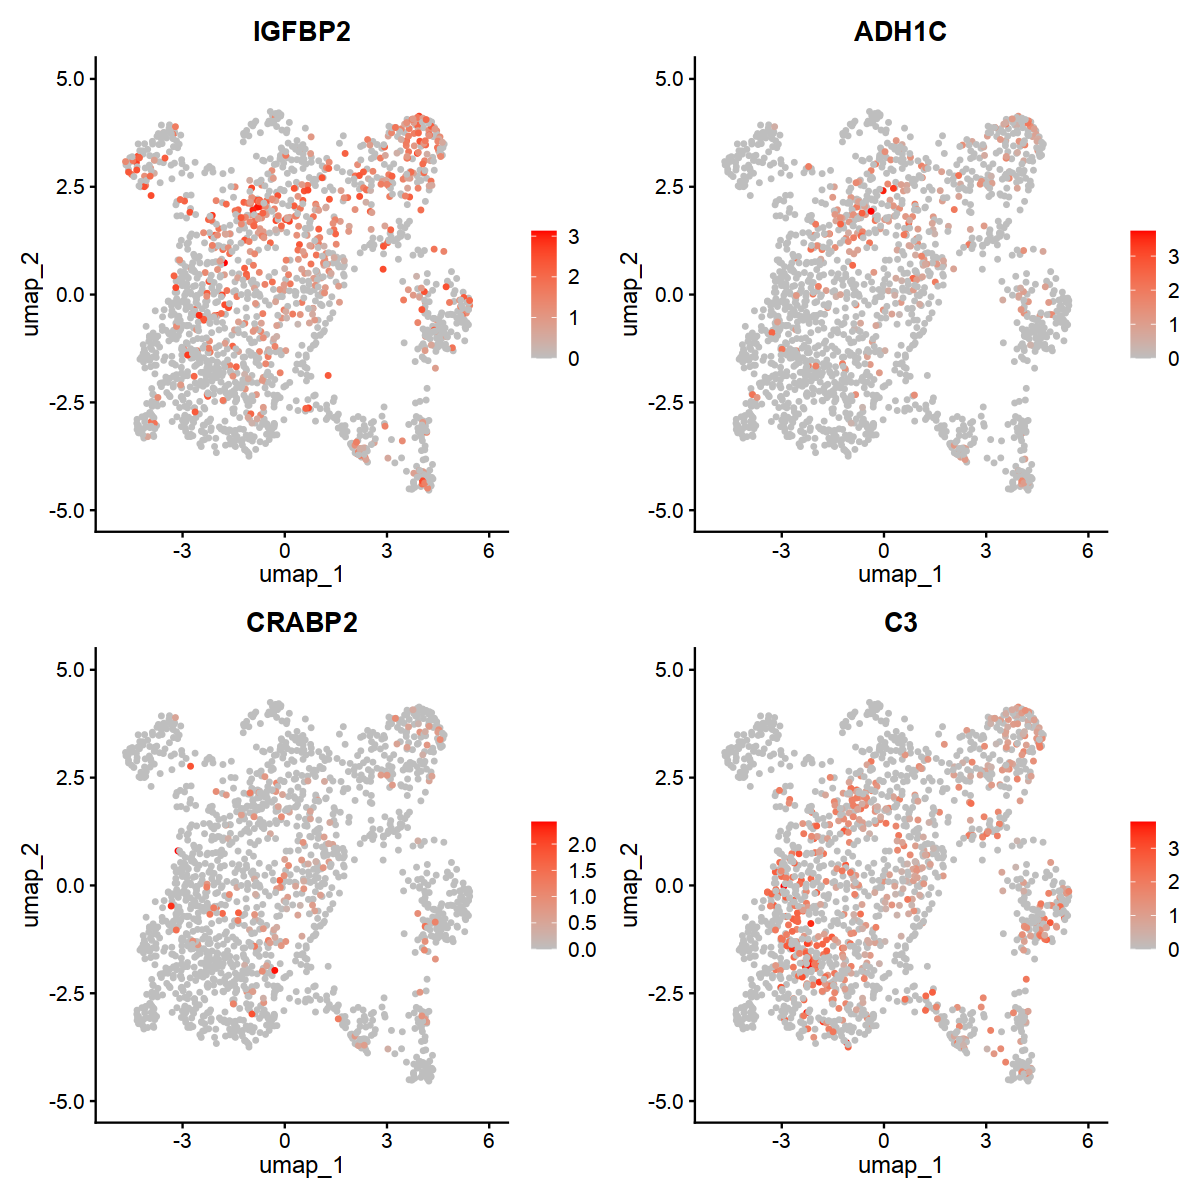

In [50]:
options(repr.plot.height=10,repr.plot.width=10)
FeaturePlot(data_epi_high2, features = c("IGFBP2",'ADH1C','CRABP2','C3'),  
           cols = c("grey","red"), reduction = "umap")

In [51]:
Idents(data_epi_high2) <- 'cnv'

In [52]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
data_epi_high2.markers <- FindAllMarkers(data_epi_high2, only.pos = TRUE)

Calculating cluster Low

Calculating cluster High



In [53]:
data_epi_high2.markers  %>%  filter(cluster=='Low')   %>% mutate(diff = (pct.1-pct.2))  %>% 
    arrange(desc(diff))

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,diff
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
CD9,2.158426e-95,1.7958845,0.803,0.318,7.900057e-91,Low,CD9,0.485
LY6E,5.120953e-49,0.7607405,0.644,0.225,1.874320e-44,Low,LY6E,0.419
RPL22L1,4.948753e-65,1.4629255,0.678,0.260,1.811293e-60,Low,RPL22L1,0.418
OST4,5.406161e-60,1.2241210,0.704,0.294,1.978709e-55,Low,OST4,0.410
PTMS,2.602682e-56,1.0204595,0.584,0.181,9.526076e-52,Low,PTMS,0.403
DDT,5.353777e-55,1.2087260,0.642,0.253,1.959536e-50,Low,DDT,0.389
PFDN5,1.952986e-54,1.1351714,0.770,0.388,7.148126e-50,Low,PFDN5,0.382
COX7A2,1.945874e-43,0.7922116,0.855,0.478,7.122093e-39,Low,COX7A2,0.377
ATP5IF1,5.198204e-46,0.9267383,0.669,0.295,1.902595e-41,Low,ATP5IF1,0.374
